# A Spatio-Temporal Machine Learning Benchmark for Forest-Habitat Disturbance Prediction around Salonga National Park

This checked v3 notebook covers the complete study pipeline and includes robust grid reconstruction from Earth Engine coveringGrid cell IDs when older exports are detected:

1. Environment setup and configuration  
2. Google Earth Engine authentication  
3. Study-area construction: Salonga National Park + 50 km buffer  
4. 10 km analysis grid with stable `cell_id` values  
5. Hansen Global Forest Change extraction, 2001–2024  
6. Static forest-habitat and optional population extraction  
7. Optional HOTOSM roads download and accessibility features  
8. Construction of the `cell_id × year` machine-learning panel  
9. Feature engineering and one-year-ahead target definition  
10. Baselines and machine-learning models  
11. Model evaluation and paper-ready figures  
12. Export of all outputs and a reproducible project ZIP  

The notebook is written for **Google Colab + Python + Google Earth Engine**.

## 0. Execution strategy

This notebook is intentionally long, but it is organized in blocks.  
For a clean execution:

1. Run Sections 1–4 to create the study area and Earth Engine export tasks.
2. Wait until all Earth Engine tasks are `COMPLETED`.
3. Run Sections 5–11 to load the exported files, build the ML panel, train models, and generate figures.
4. Run the final ZIP export section.

Earth Engine exports can take time. Do not use `getInfo()` on large `FeatureCollection` objects.

In [32]:

# =============================================================================
# 1. Install dependencies
# =============================================================================

!pip -q install earthengine-api geemap geopandas pyogrio shapely pyproj rtree mapclassify
!pip -q install scikit-learn xgboost lightgbm joblib pyarrow

In [2]:

# =============================================================================
# 2. Imports
# =============================================================================

import os
import re
import json
import time
import math
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Geospatial libraries
try:
    import geopandas as gpd
    from shapely.geometry import Point, box
except Exception as e:
    print("GeoPandas import error:", e)

# Machine learning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    brier_score_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
import joblib

# Optional models
HAS_XGB = False
HAS_LGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception as e:
    print("LightGBM unavailable:", e)

import ee

In [3]:
# =============================================================================
# 3. Global configuration
# =============================================================================

# Google Earth Engine / Google Cloud project.
# This is the project ID you successfully registered for Earth Engine.
PROJECT_ID = "charged-gravity-494904-q5"

# Study design.
PARK_NAME_KEYWORD = "Salonga"
ISO3 = "COD"
BUFFER_KM = 50
BUFFER_M = BUFFER_KM * 1000

GRID_SIZE_M = 10000       # 10 km prototype grid. Use 5000 for a 5 km sensitivity run.
GRID_KM = GRID_SIZE_M // 1000

YEARS = list(range(2001, 2025))
TREECOVER_THRESHOLD = 30  # Initial forest-habitat threshold in percent.
LOSS_EVENT_THRESHOLD_HA = 5.0

# Target split is based on the year being predicted, i.e. target_year = feature_year + 1.
TRAIN_TARGET_END = 2016
VAL_TARGET_START = 2017
VAL_TARGET_END = 2020
TEST_TARGET_START = 2021
TEST_TARGET_END = 2024

# Optional features.
ADD_WORLDPOP_2020 = True
ADD_ROADS_FEATURES = True

# Earth Engine exports.
# Options:
# - "AUTO": export only if required files are not found in Drive;
# - True  : always launch exports;
# - False : never launch exports and only load existing files.
RUN_EE_EXPORTS = "AUTO"

# Prefer a grid-size-specific export folder, but also search older export folders
# to avoid FileNotFoundError when previous exports used another folder name.
EXPORT_FOLDER = f"salonga_forest_habitat_ml_exports_{GRID_KM}km"
EXPORT_CANDIDATE_FOLDERS = [
    EXPORT_FOLDER,
    "salonga_forest_habitat_ml_exports",
    "salonga_forest_habitat_ml",
]

# Task monitoring: do not block Colab forever. If tasks are still READY/RUNNING
# after this limit, check Earth Engine > Tasks manually and rerun the loading cell later.
MAX_TASK_CHECKS = 20
TASK_SLEEP_SECONDS = 30

# Drive project folder.
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DIR = DRIVE_ROOT / "salonga_forest_habitat_ml"
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MAPS_DIR = OUTPUTS_DIR / "maps"
MODELS_DIR = OUTPUTS_DIR / "models"
PRED_DIR = OUTPUTS_DIR / "predictions"

for d in [
    PROJECT_DIR, DATA_DIR, RAW_DIR, INTERIM_DIR, PROCESSED_DIR,
    OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR, MAPS_DIR, MODELS_DIR, PRED_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# Default export folder for new Earth Engine exports.
EXPORT_DRIVE_DIR = DRIVE_ROOT / EXPORT_FOLDER
EXPORT_DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# Default expected paths. The loading cell later performs robust auto-discovery
# and can override these if files are found in another Drive folder.
LOSS_CSV = EXPORT_DRIVE_DIR / f"salonga_cell_year_loss_{GRID_KM}km.csv"
STATIC_CSV = EXPORT_DRIVE_DIR / f"salonga_cell_static_forest_{GRID_KM}km.csv"
GRID_GEOJSON = EXPORT_DRIVE_DIR / f"salonga_analysis_grid_{GRID_KM}km.geojson"
PARK_GEOJSON = EXPORT_DRIVE_DIR / "salonga_boundary.geojson"
STUDY_AREA_GEOJSON = EXPORT_DRIVE_DIR / f"salonga_buffer_{BUFFER_KM}km.geojson"

def _candidate_roots():
    """Return folders where project/export files may exist."""
    roots = []
    for folder in EXPORT_CANDIDATE_FOLDERS:
        root = DRIVE_ROOT / folder
        if root.exists():
            roots.append(root)
    if PROJECT_DIR.exists() and PROJECT_DIR not in roots:
        roots.append(PROJECT_DIR)
    return roots

def find_latest_file(patterns, roots=None, required=False, label="file"):
    """Find the most recent file matching one or more glob patterns."""
    if isinstance(patterns, str):
        patterns = [patterns]
    roots = roots or _candidate_roots()

    matches = []
    for root in roots:
        for pattern in patterns:
            matches.extend(root.rglob(pattern))

    # Last fallback: search the whole Drive, but only if not found in known roots.
    if not matches:
        for pattern in patterns:
            matches.extend(DRIVE_ROOT.rglob(pattern))

    matches = [p for p in matches if p.is_file()]

    if not matches:
        if required:
            searched = "\n".join(str(r) for r in roots)
            raise FileNotFoundError(
                f"No {label} found for patterns {patterns}.\n"
                f"Searched roots:\n{searched}\n"
                "If Earth Engine exports are still READY/RUNNING, wait until they are COMPLETED."
            )
        return None

    matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)
    print(f"Selected {label}: {matches[0]}")
    return matches[0]

print("Project folder:", PROJECT_DIR)
print("New Earth Engine export folder:", EXPORT_FOLDER)
print("RUN_EE_EXPORTS:", RUN_EE_EXPORTS)
print("Default expected loss CSV:", LOSS_CSV)
print("Default expected static CSV:", STATIC_CSV)


Mounted at /content/drive
Project folder: /content/drive/MyDrive/salonga_forest_habitat_ml
New Earth Engine export folder: salonga_forest_habitat_ml_exports_10km
RUN_EE_EXPORTS: AUTO
Default expected loss CSV: /content/drive/MyDrive/salonga_forest_habitat_ml_exports_10km/salonga_cell_year_loss_10km.csv
Default expected static CSV: /content/drive/MyDrive/salonga_forest_habitat_ml_exports_10km/salonga_cell_static_forest_10km.csv


## 1. Earth Engine initialization

In [4]:

# =============================================================================
# 4. Earth Engine authentication and initialization
# =============================================================================

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized successfully with project:", PROJECT_ID)

Earth Engine initialized successfully with project: charged-gravity-494904-q5


## 2. Study area: Salonga National Park + 50 km buffer

The study area is defined as Salonga National Park plus an external 50 km buffer.  
The analysis grid is clipped to this exact study area to avoid counting pixels outside the intended perimeter.

In [5]:

# =============================================================================
# 5. Load Salonga boundary from WDPA and build clipped grid
# =============================================================================

wdpa = ee.FeatureCollection("WCMC/WDPA/current/polygons")

salonga = wdpa.filter(
    ee.Filter.And(
        ee.Filter.eq("ISO3", ISO3),
        ee.Filter.stringContains("NAME", PARK_NAME_KEYWORD)
    )
)

salonga_size = salonga.size().getInfo()
print("WDPA Salonga features found:", salonga_size)

if salonga_size == 0:
    raise ValueError("No Salonga feature found in WDPA. Check the NAME filter or WDPA attributes.")

salonga_geom = salonga.geometry()
study_area_geom = salonga_geom.buffer(BUFFER_M)

# Earth Engine projection used for a metric grid.
grid_proj = ee.Projection("EPSG:3857").atScale(GRID_SIZE_M)

raw_grid = study_area_geom.coveringGrid(grid_proj)

def make_stable_cell_id(geom):
    # Use centroid coordinates rounded at 1e-5 degree precision.
    centroid = geom.centroid(ee.ErrorMargin(1))
    coords = centroid.coordinates()
    lon_code = ee.Number(coords.get(0)).multiply(100000).round().format("%d")
    lat_code = ee.Number(coords.get(1)).multiply(100000).round().format("%d")
    return ee.String("cell_").cat(lon_code).cat("_").cat(lat_code)

def classify_zone(distance_m, inside):
    return ee.String(
        ee.Algorithms.If(
            inside, "inside_park",
            ee.Algorithms.If(
                distance_m.lte(10000), "buffer_0_10km",
                ee.Algorithms.If(
                    distance_m.lte(25000), "buffer_10_25km",
                    "buffer_25_50km"
                )
            )
        )
    )

def clip_and_attribute_cell(f):
    clipped_geom = f.geometry().intersection(study_area_geom, ee.ErrorMargin(1))
    area_ha = clipped_geom.area(ee.ErrorMargin(1)).divide(10000)
    centroid = clipped_geom.centroid(ee.ErrorMargin(1))

    inside = salonga_geom.contains(centroid, ee.ErrorMargin(1))
    distance_to_park = centroid.distance(salonga_geom, ee.ErrorMargin(1))
    zone = classify_zone(distance_to_park, inside)
    cell_id = make_stable_cell_id(clipped_geom)

    return ee.Feature(clipped_geom, {
        "cell_id": cell_id,
        "zone": zone,
        "inside_park": inside,
        "distance_to_park_m": distance_to_park,
        "cell_area_ha": area_ha,
        "grid_size_m": GRID_SIZE_M,
        "buffer_km": BUFFER_KM
    })

grid = (
    raw_grid
    .map(clip_and_attribute_cell)
    .filter(ee.Filter.gt("cell_area_ha", 0.01))
)

n_cells = grid.size().getInfo()
print("Analysis cells:", n_cells)
print("Expected cell-year rows:", n_cells * len(YEARS))

WDPA Salonga features found: 2
Analysis cells: 1056
Expected cell-year rows: 25344


In [6]:

# =============================================================================
# 6. Optional quick interactive map
# =============================================================================

try:
    import geemap
    m = geemap.Map(center=[-2.5, 21.0], zoom=6)
    m.addLayer(study_area_geom, {"color": "blue"}, "Salonga + 50 km buffer")
    m.addLayer(salonga_geom, {"color": "green"}, "Salonga National Park")
    m.addLayer(grid.limit(500), {"color": "gray"}, f"Analysis grid {GRID_KM} km (first 500)")
    m
except Exception as e:
    print("Interactive map unavailable:", e)

## 3. Earth Engine extraction: annual forest-habitat disturbance and static forest features

The annual disturbance extraction uses a **multi-band image** with one band per year.  
This avoids Earth Engine's `Too many concurrent aggregations` error caused by launching one `reduceRegions()` per year.

In [7]:

# =============================================================================
# 7. Hansen Global Forest Change and optional WorldPop loading
# =============================================================================

hansen = ee.Image("UMD/hansen/global_forest_change_2024_v1_12")

treecover2000 = hansen.select("treecover2000")
lossyear = hansen.select("lossyear")
loss = hansen.select("loss")
datamask = hansen.select("datamask")

pixel_area_ha = ee.Image.pixelArea().divide(10000)

# Initial forest-habitat mask.
forest2000_mask = treecover2000.gte(TREECOVER_THRESHOLD).And(datamask.eq(1))

# Optional WorldPop image.
worldpop_available = False
pop_image = None

if ADD_WORLDPOP_2020:
    try:
        worldpop_ic = (
            ee.ImageCollection("WorldPop/GP/100m/pop")
            .filter(ee.Filter.eq("country", ISO3))
            .filter(ee.Filter.eq("year", 2020))
        )
        wp_size = worldpop_ic.size().getInfo()
        print("WorldPop 2020 images found:", wp_size)
        if wp_size > 0:
            pop_image = ee.Image(worldpop_ic.first()).select("population").rename("population_2020")
            worldpop_available = True
    except Exception as e:
        print("WorldPop unavailable or inaccessible:", e)
        worldpop_available = False

print("WorldPop enabled:", worldpop_available)

WorldPop 2020 images found: 1
WorldPop enabled: True


In [8]:

# =============================================================================
# 8. Build annual disturbance FeatureCollection using one multi-band aggregation
# =============================================================================

def make_annual_loss_band(year):
    year_int = int(year)
    year_code = year_int - 2000

    annual_loss_mask = lossyear.eq(year_code).And(forest2000_mask)

    return (
        annual_loss_mask
        .multiply(pixel_area_ha)
        .rename(f"loss_area_ha_{year_int}")
    )

annual_loss_stack = ee.Image.cat([make_annual_loss_band(y) for y in YEARS])

wide_loss_stats = annual_loss_stack.reduceRegions(
    collection=grid,
    reducer=ee.Reducer.sum(),
    scale=30,
    tileScale=16
)

def wide_cell_to_long_years(f):
    props = f.toDictionary()

    def make_year_feature(year):
        year = ee.Number(year)
        band_name = ee.String("loss_area_ha_").cat(year.format("%d"))

        raw_loss_area = props.get(band_name)
        loss_area = ee.Number(ee.Algorithms.If(raw_loss_area, raw_loss_area, 0))
        loss_event = loss_area.gte(LOSS_EVENT_THRESHOLD_HA)

        return ee.Feature(None, {
            "cell_id": f.get("cell_id"),
            "year": year,
            "loss_area_ha": loss_area,
            "loss_event": loss_event,
            "loss_event_threshold_ha": LOSS_EVENT_THRESHOLD_HA,
            "zone": f.get("zone"),
            "inside_park": f.get("inside_park"),
            "distance_to_park_m": f.get("distance_to_park_m"),
            "cell_area_ha": f.get("cell_area_ha"),
            "grid_size_m": GRID_SIZE_M,
            "treecover_threshold": TREECOVER_THRESHOLD
        })

    return ee.FeatureCollection(ee.List(YEARS).map(make_year_feature))

loss_fc = wide_loss_stats.map(wide_cell_to_long_years).flatten()

print("Annual loss FeatureCollection prepared.")
print("Expected rows:", n_cells * len(YEARS))
print("No heavy getInfo() preview is used.")

Annual loss FeatureCollection prepared.
Expected rows: 25344
No heavy getInfo() preview is used.


In [9]:

# =============================================================================
# 9. Build static forest-habitat FeatureCollection
# =============================================================================

forest_area_2000_ha = (
    forest2000_mask
    .multiply(pixel_area_ha)
    .rename("forest_area_2000_ha")
)

treecover_masked = (
    treecover2000
    .updateMask(datamask.eq(1))
    .rename("treecover2000")
)

static_bands = [forest_area_2000_ha, treecover_masked]

if worldpop_available:
    static_bands.append(pop_image)

static_image = ee.Image.cat(static_bands)

# Combined reducer yields sum and mean properties for each band.
static_reducer = ee.Reducer.sum().combine(
    reducer2=ee.Reducer.mean(),
    sharedInputs=True
)

static_raw = static_image.reduceRegions(
    collection=grid,
    reducer=static_reducer,
    scale=100,
    tileScale=16
)

def clean_static_feature(f):
    forest_area = ee.Number(ee.Algorithms.If(f.get("forest_area_2000_ha_sum"), f.get("forest_area_2000_ha_sum"), 0))
    tree_mean = ee.Number(ee.Algorithms.If(f.get("treecover2000_mean"), f.get("treecover2000_mean"), 0))

    base_props = {
        "cell_id": f.get("cell_id"),
        "zone": f.get("zone"),
        "inside_park": f.get("inside_park"),
        "distance_to_park_m": f.get("distance_to_park_m"),
        "cell_area_ha": f.get("cell_area_ha"),
        "grid_size_m": GRID_SIZE_M,
        "treecover_threshold": TREECOVER_THRESHOLD,
        "forest_area_2000_ha": forest_area,
        "treecover2000_mean": tree_mean
    }

    if worldpop_available:
        pop_sum = ee.Number(ee.Algorithms.If(f.get("population_2020_sum"), f.get("population_2020_sum"), 0))
        pop_mean = ee.Number(ee.Algorithms.If(f.get("population_2020_mean"), f.get("population_2020_mean"), 0))
        base_props["population_2020_sum"] = pop_sum
        base_props["population_2020_mean"] = pop_mean

    return ee.Feature(None, base_props)

static_fc = static_raw.map(clean_static_feature)

print("Static forest-habitat FeatureCollection prepared.")

Static forest-habitat FeatureCollection prepared.


## 4. Export Earth Engine data to Google Drive

Run the next cell once.  
Then wait until all tasks are completed before loading the CSV/GeoJSON files.

In [10]:
# =============================================================================
# 10. Export Earth Engine tables
# =============================================================================

grid_prefix = f"salonga_analysis_grid_{GRID_KM}km"
loss_prefix = f"salonga_cell_year_loss_{GRID_KM}km"
static_prefix = f"salonga_cell_static_forest_{GRID_KM}km"

# Check whether important exports already exist anywhere in Drive.
existing_loss = find_latest_file(f"{loss_prefix}*.csv", required=False, label="existing loss CSV")
existing_static = find_latest_file(f"{static_prefix}*.csv", required=False, label="existing static CSV")
existing_grid = find_latest_file(
    [f"{grid_prefix}*.geojson", f"*grid*{GRID_KM}km*.geojson"],
    required=False,
    label="existing grid GeoJSON"
)

if RUN_EE_EXPORTS == "AUTO":
    should_export = not (existing_loss and existing_static and existing_grid)
else:
    should_export = bool(RUN_EE_EXPORTS)

tasks = []

if should_export:
    print("Starting Earth Engine export tasks.")
    print("Note: only missing exports are started when existing files are detected.")

    if not existing_grid or RUN_EE_EXPORTS is True:
        grid_task = ee.batch.Export.table.toDrive(
            collection=grid,
            description=grid_prefix,
            folder=EXPORT_FOLDER,
            fileNamePrefix=grid_prefix,
            fileFormat="GeoJSON"
        )
        tasks.append(("grid", grid_task))

    # Park and study-area boundaries are useful for maps, but not required for ML.
    existing_park = find_latest_file("salonga_boundary*.geojson", required=False, label="existing park boundary")
    if not existing_park or RUN_EE_EXPORTS is True:
        park_task = ee.batch.Export.table.toDrive(
            collection=salonga,
            description="salonga_boundary",
            folder=EXPORT_FOLDER,
            fileNamePrefix="salonga_boundary",
            fileFormat="GeoJSON"
        )
        tasks.append(("park", park_task))

    existing_buffer = find_latest_file(
        [f"salonga_buffer_{BUFFER_KM}km*.geojson", f"*buffer*{BUFFER_KM}km*.geojson"],
        required=False,
        label="existing study-area buffer"
    )
    if not existing_buffer or RUN_EE_EXPORTS is True:
        study_area_task = ee.batch.Export.table.toDrive(
            collection=ee.FeatureCollection([
                ee.Feature(study_area_geom, {"name": f"Salonga_buffer_{BUFFER_KM}km"})
            ]),
            description=f"salonga_buffer_{BUFFER_KM}km",
            folder=EXPORT_FOLDER,
            fileNamePrefix=f"salonga_buffer_{BUFFER_KM}km",
            fileFormat="GeoJSON"
        )
        tasks.append(("study_area", study_area_task))

    if not existing_loss or RUN_EE_EXPORTS is True:
        loss_task = ee.batch.Export.table.toDrive(
            collection=loss_fc,
            description=loss_prefix,
            folder=EXPORT_FOLDER,
            fileNamePrefix=loss_prefix,
            fileFormat="CSV"
        )
        tasks.append(("loss", loss_task))

    if not existing_static or RUN_EE_EXPORTS is True:
        static_task = ee.batch.Export.table.toDrive(
            collection=static_fc,
            description=static_prefix,
            folder=EXPORT_FOLDER,
            fileNamePrefix=static_prefix,
            fileFormat="CSV"
        )
        tasks.append(("static", static_task))

    if tasks:
        for name, task in tasks:
            task.start()
            print(f"Started task: {name} | {task.id}")

        print("\nWait until the required tasks are COMPLETED before proceeding to the loading section.")
        print("If they remain READY for a long time, check Earth Engine > Tasks and cancel duplicate READY tasks.")
    else:
        print("All required files were already found. No new export task started.")
else:
    print("Earth Engine exports skipped.")
    print("Existing files will be loaded from Google Drive in the next section.")


Selected existing loss CSV: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_cell_year_loss_10km.csv
Selected existing static CSV: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_cell_static_forest_10km.csv
Selected existing grid GeoJSON: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_grid_10km_buffer50km.geojson
Earth Engine exports skipped.
Existing files will be loaded from Google Drive in the next section.


In [11]:
# =============================================================================
# 11. Monitor Earth Engine tasks started in this session
# =============================================================================

if "tasks" in globals() and tasks:
    for i in range(MAX_TASK_CHECKS):
        print("-" * 60)
        print(f"Check {i + 1}/{MAX_TASK_CHECKS}")

        all_done = True
        for name, task in tasks:
            status = task.status()
            state = status.get("state")
            print(f" - {name}: {state}")

            if state not in ["COMPLETED", "FAILED", "CANCELLED"]:
                all_done = False

        if all_done:
            print("All tasks finished.")
            break

        time.sleep(TASK_SLEEP_SECONDS)

    print("\nCurrent task statuses:")
    for name, task in tasks:
        print(f"\n{name}:")
        print(task.status())

    print(
        "\nIf some tasks are still READY/RUNNING, do not relaunch exports. "
        "Wait in Earth Engine > Tasks, then rerun only the loading cell."
    )
else:
    print("No task objects found in this session, or no exports were needed.")
    print("Proceed to the loading section if the CSV/GeoJSON files already exist in Drive.")


No task objects found in this session, or no exports were needed.
Proceed to the loading section if the CSV/GeoJSON files already exist in Drive.


## 5. Load exported Earth Engine outputs

Run this section after all exports are completed.

In [12]:

# =============================================================================
# 12. Load exported files from Google Drive
# =============================================================================
#
# This cell is intentionally strict and publishable.
# It loads loss/static CSV files as the authoritative ML tables and then tries
# to attach a compatible grid geometry for maps, road features, and neighbour
# pressure features. If an older GeoJSON has incompatible IDs, it reconstructs
# grid-square geometries from Earth Engine coveringGrid IDs such as "225,-42".

LOSS_CSV = find_latest_file(
    [f"salonga_cell_year_loss_{GRID_KM}km.csv", f"salonga_cell_year_loss_{GRID_KM}km*.csv"],
    required=True,
    label="loss CSV"
)

STATIC_CSV = find_latest_file(
    [f"salonga_cell_static_forest_{GRID_KM}km.csv", f"salonga_cell_static_forest_{GRID_KM}km*.csv"],
    required=True,
    label="static forest CSV"
)

GRID_GEOJSON = find_latest_file(
    [
        f"salonga_analysis_grid_{GRID_KM}km.geojson",
        f"salonga_analysis_grid_{GRID_KM}km*.geojson",
        f"*grid*{GRID_KM}km*.geojson",
    ],
    required=False,
    label="analysis grid GeoJSON"
)

# Optional files used only for nicer maps. Avoid accidentally using a grid file
# as a buffer/study-area file, because old project folders may contain names such
# as salonga_grid_10km_buffer50km.geojson.
PARK_GEOJSON_FOUND = find_latest_file(
    ["salonga_boundary.geojson", "salonga_boundary*.geojson"],
    required=False,
    label="park boundary GeoJSON"
)
if PARK_GEOJSON_FOUND is not None:
    PARK_GEOJSON = PARK_GEOJSON_FOUND

STUDY_AREA_GEOJSON_FOUND = find_latest_file(
    [
        f"salonga_buffer_{BUFFER_KM}km.geojson",
        f"salonga_buffer_{BUFFER_KM}km*.geojson",
        f"salonga_study_area_buffer{BUFFER_KM}km*.geojson",
        f"salonga_study_zones_buffer{BUFFER_KM}km*.geojson",
    ],
    required=False,
    label="study-area buffer GeoJSON"
)
if STUDY_AREA_GEOJSON_FOUND is not None and "grid" not in STUDY_AREA_GEOJSON_FOUND.name.lower():
    STUDY_AREA_GEOJSON = STUDY_AREA_GEOJSON_FOUND
else:
    if STUDY_AREA_GEOJSON_FOUND is not None:
        print("Ignoring study-area candidate because it is actually a grid file:", STUDY_AREA_GEOJSON_FOUND)

loss_df = pd.read_csv(LOSS_CSV)
static_df = pd.read_csv(STATIC_CSV)

required_loss_cols = {"cell_id", "year", "loss_area_ha", "loss_event"}
required_static_cols = {"cell_id", "forest_area_2000_ha", "treecover2000_mean"}

missing_loss = required_loss_cols - set(loss_df.columns)
missing_static = required_static_cols - set(static_df.columns)

if missing_loss:
    raise ValueError(f"Loss CSV is missing required columns: {sorted(missing_loss)}")
if missing_static:
    raise ValueError(f"Static CSV is missing required columns: {sorted(missing_static)}")

# Normalize IDs before checks.
loss_df["cell_id"] = loss_df["cell_id"].astype(str)
static_df["cell_id"] = static_df["cell_id"].astype(str)

loss_ids = set(loss_df["cell_id"].unique())
static_ids = set(static_df["cell_id"].unique())
analysis_ids = loss_ids & static_ids

if not analysis_ids:
    raise ValueError(
        "No common cell_id values between loss and static tables. "
        "The loss and static exports must come from the same Earth Engine grid."
    )

def reconstruct_grid_from_coveringgrid_ids(cell_ids, grid_size_m=GRID_SIZE_M):
    """Reconstruct approximate EPSG:3857 grid squares from EE coveringGrid IDs.

    Earth Engine coveringGrid may produce IDs like "225,-42". These IDs encode
    the integer grid column and row in the projection used to build the grid.
    For EPSG:3857 at 10 km scale, cell "225,-42" corresponds approximately to
    x=[225*10000, 226*10000], y=[-42*10000, -41*10000].

    The reconstructed squares are used only for maps, road-distance features,
    and neighbour features. Loss/static statistics remain those exported by
    Earth Engine on the clipped study-area geometry.
    """
    ids = sorted(str(cid) for cid in cell_ids)
    parsed = []
    for cid in ids:
        m = re.fullmatch(r"(-?\d+),(-?\d+)", cid)
        if not m:
            return None
        col, row = int(m.group(1)), int(m.group(2))
        x0 = col * grid_size_m
        x1 = (col + 1) * grid_size_m
        y0 = row * grid_size_m
        y1 = (row + 1) * grid_size_m
        parsed.append((cid, box(min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))))

    return gpd.GeoDataFrame(
        {"cell_id": [p[0] for p in parsed]},
        geometry=[p[1] for p in parsed],
        crs="EPSG:3857"
    ).to_crs(epsg=4326)

grid_gdf = None
GRID_GDF_AVAILABLE = False

# 1) Try loading the discovered GeoJSON.
if GRID_GEOJSON is not None:
    try:
        candidate_grid = gpd.read_file(GRID_GEOJSON)
        if "cell_id" in candidate_grid.columns:
            candidate_grid["cell_id"] = candidate_grid["cell_id"].astype(str)
            candidate_ids = set(candidate_grid["cell_id"].unique())
            n_common = len(analysis_ids & candidate_ids)
            print("Loaded candidate grid:", GRID_GEOJSON)
            print("Candidate grid cells:", len(candidate_ids))
            print("Common cells with loss/static:", n_common)

            if n_common > 0:
                grid_gdf = candidate_grid[candidate_grid["cell_id"].isin(analysis_ids)].copy()
                GRID_GDF_AVAILABLE = True
            else:
                print("Candidate grid has incompatible cell_id values; it will not be used.")
        else:
            print("Candidate grid has no cell_id column; it will not be used.")
    except Exception as e:
        print("Could not read candidate grid GeoJSON:", e)

# 2) If Drive GeoJSON is incompatible, rebuild from the live EE object if possible.
if not GRID_GDF_AVAILABLE:
    try:
        print("Attempting to rebuild compatible grid_gdf from the live Earth Engine `grid` object...")
        grid_gdf = geemap.ee_to_gdf(grid)
        grid_gdf["cell_id"] = grid_gdf["cell_id"].astype(str)
        grid_gdf = grid_gdf[grid_gdf["cell_id"].isin(analysis_ids)].copy()
        if len(grid_gdf) > 0:
            GRID_GDF_AVAILABLE = True
            print("Rebuilt compatible grid_gdf from Earth Engine:", grid_gdf.shape)
        else:
            print("Earth Engine grid was rebuilt, but no common cell_id values were found.")
    except Exception as e:
        print("Could not rebuild grid from Earth Engine.")
        print("Reason:", e)

# 3) Reconstruct from coveringGrid IDs like "225,-42". This fixes older exports.
if not GRID_GDF_AVAILABLE:
    reconstructed = reconstruct_grid_from_coveringgrid_ids(analysis_ids, GRID_SIZE_M)
    if reconstructed is not None and len(reconstructed) > 0:
        # Attach metadata from static table when available.
        meta_cols = [c for c in ["cell_id", "zone", "inside_park", "distance_to_park_m", "cell_area_ha", "grid_size_m", "treecover_threshold"] if c in static_df.columns]
        if len(meta_cols) > 1:
            reconstructed = reconstructed.merge(static_df[meta_cols].drop_duplicates("cell_id"), on="cell_id", how="left")
        grid_gdf = reconstructed
        GRID_GDF_AVAILABLE = True
        repaired_grid_path = PROJECT_DIR / f"salonga_analysis_grid_{GRID_KM}km_reconstructed_from_ids.geojson"
        grid_gdf.to_file(repaired_grid_path, driver="GeoJSON")
        GRID_GEOJSON = repaired_grid_path
        print("Reconstructed compatible grid geometry from coveringGrid cell_id values:", grid_gdf.shape)
        print("Saved reconstructed grid:", repaired_grid_path)

# 4) Last-resort minimal grid table without geometry.
if not GRID_GDF_AVAILABLE:
    grid_gdf = gpd.GeoDataFrame(
        {"cell_id": sorted(analysis_ids)},
        geometry=[None] * len(analysis_ids),
        crs="EPSG:4326"
    )
    print("Created minimal grid_gdf without geometry. Maps and spatial-neighbour features will be skipped.")

print("\nLoaded tables:")
print(" - loss_df:", loss_df.shape)
print(" - static_df:", static_df.shape)
print(" - grid_gdf:", grid_gdf.shape)
print(" - GRID_GDF_AVAILABLE:", GRID_GDF_AVAILABLE)

grid_ids = set(grid_gdf["cell_id"].astype(str).unique())

print("\nCell-id consistency:")
print(" - loss cells:", len(loss_ids))
print(" - static cells:", len(static_ids))
print(" - grid cells:", len(grid_ids))
print(" - common loss/static:", len(analysis_ids))
print(" - common loss/static/grid:", len(analysis_ids & grid_ids))
print(" - loss rows:", len(loss_df))
print(" - expected loss rows from unique cells × years:", len(loss_ids) * loss_df["year"].nunique())

if GRID_GDF_AVAILABLE and len(analysis_ids & grid_ids) != len(analysis_ids):
    print("Warning: not all analysis cells have geometry. Maps/features will use the available subset.")

display(loss_df.head())
display(static_df.head())
display(grid_gdf.head())


Selected loss CSV: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_cell_year_loss_10km.csv
Selected static forest CSV: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_cell_static_forest_10km.csv
Selected analysis grid GeoJSON: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_grid_10km_buffer50km.geojson
Selected study-area buffer GeoJSON: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_study_zones_buffer50km.geojson
Loaded candidate grid: /content/drive/MyDrive/salonga_forest_habitat_ml/salonga_grid_10km_buffer50km.geojson
Candidate grid cells: 1055
Common cells with loss/static: 0
Candidate grid has incompatible cell_id values; it will not be used.
Attempting to rebuild compatible grid_gdf from the live Earth Engine `grid` object...
Earth Engine grid was rebuilt, but no common cell_id values were found.
Reconstructed compatible grid geometry from coveringGrid cell_id values: (1056, 7)
Saved reconstructed grid: /content/drive/MyDrive/salonga_forest_ha

,system:index,cell_id,distance_to_park_m,grid_size_m,inside_park,loss_area_ha,loss_event,loss_event_threshold_ha,treecover_threshold,year,zone,.geo
0,"225,-42_0","225,-42",48758.64491,10000,False,0.0,0,5,30,2001,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,"225,-42_1","225,-42",48758.64491,10000,False,0.0,0,5,30,2002,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,"225,-42_2","225,-42",48758.64491,10000,False,0.0,0,5,30,2003,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,"225,-42_3","225,-42",48758.64491,10000,False,0.0,0,5,30,2004,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,"225,-42_4","225,-42",48758.64491,10000,False,0.0,0,5,30,2005,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"


,system:index,cell_id,distance_to_park_m,forest_area_2000_ha,grid_size_m,inside_park,treecover2000_mean,treecover_threshold,zone,.geo
0,"225,-42","225,-42",48758.644910,1034.915070,10000,False,94.968632,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,"226,-42","226,-42",47008.828279,4876.714013,10000,False,87.973368,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,"227,-42","227,-42",45586.265431,6418.903239,10000,False,72.349598,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,"228,-42","228,-42",44943.491108,9226.348701,10000,False,97.301283,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,"229,-42","229,-42",45471.518999,8438.025120,10000,False,99.225104,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"


,cell_id,geometry,zone,inside_park,distance_to_park_m,grid_size_m,treecover_threshold
0,"218,-19","POLYGON ((19.6731 -1.70655, 19.6731 -1.61675, ...",buffer_25_50km,False,49764.709087,10000,30
1,"218,-20","POLYGON ((19.6731 -1.79634, 19.6731 -1.70655, ...",buffer_25_50km,False,49399.747218,10000,30
2,"218,-21","POLYGON ((19.6731 -1.88612, 19.6731 -1.79634, ...",buffer_25_50km,False,49555.447822,10000,30
3,"218,-22","POLYGON ((19.6731 -1.9759, 19.6731 -1.88612, 1...",buffer_25_50km,False,50040.139287,10000,30
4,"219,-17","POLYGON ((19.76294 -1.52696, 19.76294 -1.43715...",buffer_25_50km,False,49047.115682,10000,30


In [13]:

# =============================================================================
# 13. Cache exports as Parquet for faster reruns
# =============================================================================

loss_parquet = PROCESSED_DIR / f"salonga_cell_year_loss_{GRID_KM}km.parquet"
static_parquet = PROCESSED_DIR / f"salonga_cell_static_forest_{GRID_KM}km.parquet"
grid_file = PROCESSED_DIR / f"salonga_analysis_grid_{GRID_KM}km.geojson"

loss_df.to_parquet(loss_parquet, index=False)
static_df.to_parquet(static_parquet, index=False)

if GRID_GDF_AVAILABLE and grid_gdf.geometry.notna().any():
    grid_gdf.to_file(grid_file, driver="GeoJSON")
    print("Cached grid:", grid_file)
else:
    print("Grid geometry is unavailable; skipping grid GeoJSON cache.")

print("Cached:")
print(loss_parquet)
print(static_parquet)


Cached grid: /content/drive/MyDrive/salonga_forest_habitat_ml/data/processed/salonga_analysis_grid_10km.geojson
Cached:
/content/drive/MyDrive/salonga_forest_habitat_ml/data/processed/salonga_cell_year_loss_10km.parquet
/content/drive/MyDrive/salonga_forest_habitat_ml/data/processed/salonga_cell_static_forest_10km.parquet


## 6. Optional roads/accessibility features

This section downloads HOTOSM roads for the Democratic Republic of the Congo and derives two accessibility indicators:

- distance to nearest road;
- road density inside each grid cell.

If the download fails, the notebook continues without road features.

In [14]:

# =============================================================================
# 14. Optional HOTOSM roads download and accessibility features
# =============================================================================

roads_features_path = PROCESSED_DIR / f"salonga_roads_features_{GRID_KM}km.parquet"
analysis_cell_ids = sorted(set(loss_df["cell_id"].astype(str)) & set(static_df["cell_id"].astype(str)))

def make_empty_road_features(cell_ids):
    out = pd.DataFrame({"cell_id": list(cell_ids)})
    out["distance_to_road_m"] = np.nan
    out["road_length_km"] = np.nan
    out["cell_area_km2"] = np.nan
    out["road_density_km_per_km2"] = np.nan
    return out

if ADD_ROADS_FEATURES and GRID_GDF_AVAILABLE and grid_gdf.geometry.notna().any():
    import requests

    roads_dir = RAW_DIR / "roads"
    roads_dir.mkdir(parents=True, exist_ok=True)

    # HDX/HOTOSM DRC roads resource.
    ROADS_URL = "https://data.humdata.org/dataset/f8dfa780-d149-4a20-808f-d597d964cc0f/resource/55e99206-72bd-46de-93ce-6d1089a7bad5/download/hotosm_cod_roads_lines_shp.zip"
    roads_zip = roads_dir / "hotosm_cod_roads_lines_shp.zip"

    try:
        if not roads_zip.exists():
            print("Downloading HOTOSM roads...")
            r = requests.get(ROADS_URL, timeout=120)
            r.raise_for_status()
            roads_zip.write_bytes(r.content)
            print("Downloaded:", roads_zip)
        else:
            print("Roads ZIP already exists:", roads_zip)

        extract_dir = roads_dir / "hotosm_cod_roads_lines_shp"
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(roads_zip, "r") as z:
            z.extractall(extract_dir)

        shp_files = list(extract_dir.rglob("*.shp"))
        if not shp_files:
            raise FileNotFoundError("No .shp file found after extracting HOTOSM roads.")

        roads_gdf = gpd.read_file(shp_files[0])
        print("Raw roads:", roads_gdf.shape)

        # Reproject.
        grid_metric = grid_gdf[grid_gdf["cell_id"].astype(str).isin(analysis_cell_ids)].to_crs(epsg=3857).copy()
        roads_metric = roads_gdf.to_crs(epsg=3857).copy()

        # Clip/filter roads by study-area grid bounds.
        bounds_geom = grid_metric.unary_union
        roads_metric = roads_metric[roads_metric.intersects(bounds_geom)].copy()
        print("Roads intersecting study area:", roads_metric.shape)

        if roads_metric.empty:
            raise ValueError("No roads intersect the study area.")

        # Union for distance.
        try:
            road_union = roads_metric.geometry.union_all()
        except Exception:
            road_union = roads_metric.unary_union

        grid_metric["centroid_geom"] = grid_metric.geometry.centroid
        grid_metric["distance_to_road_m"] = grid_metric["centroid_geom"].distance(road_union)

        # Road density per cell.
        road_lengths = []
        for geom in grid_metric.geometry:
            subset = roads_metric[roads_metric.intersects(geom)]
            if subset.empty:
                road_lengths.append(0.0)
            else:
                road_lengths.append(subset.geometry.intersection(geom).length.sum() / 1000.0)

        grid_metric["road_length_km"] = road_lengths
        grid_metric["cell_area_km2"] = grid_metric.geometry.area / 1_000_000
        grid_metric["road_density_km_per_km2"] = grid_metric["road_length_km"] / grid_metric["cell_area_km2"].replace(0, np.nan)

        roads_features = grid_metric[[
            "cell_id",
            "distance_to_road_m",
            "road_length_km",
            "cell_area_km2",
            "road_density_km_per_km2"
        ]].copy()

        roads_features.to_parquet(roads_features_path, index=False)
        print("Saved road features:", roads_features_path)
        display(roads_features.head())

    except Exception as e:
        print("Road feature extraction failed. Continuing without roads.")
        print("Reason:", e)
        roads_features = make_empty_road_features(analysis_cell_ids)
        roads_features.to_parquet(roads_features_path, index=False)

else:
    if not ADD_ROADS_FEATURES:
        print("ADD_ROADS_FEATURES=False. Skipping roads.")
    else:
        print("Grid geometry is unavailable. Skipping road-distance and road-density features.")
    roads_features = make_empty_road_features(analysis_cell_ids)
    roads_features.to_parquet(roads_features_path, index=False)


Downloaded: /content/drive/MyDrive/salonga_forest_habitat_ml/data/raw/roads/hotosm_cod_roads_lines_shp.zip
Raw roads: (667582, 15)
Roads intersecting study area: (931, 15)
Saved road features: /content/drive/MyDrive/salonga_forest_habitat_ml/data/processed/salonga_roads_features_10km.parquet


,cell_id,distance_to_road_m,road_length_km,cell_area_km2,road_density_km_per_km2
0,"218,-19",16704.454060,0.000000,100.0,0.000000
1,"218,-20",14767.186646,0.000000,100.0,0.000000
2,"218,-21",5228.702071,2.890949,100.0,0.028909
3,"218,-22",3680.535835,11.896948,100.0,0.118969
4,"219,-17",18264.405658,0.000000,100.0,0.000000


## 7. Build the spatio-temporal machine-learning panel

In [15]:

# =============================================================================
# 15. Utility functions for cleaning
# =============================================================================

def to_binary_bool(s):
    if isinstance(s, pd.Series):
        return (
            s.astype(str)
            .str.lower()
            .map({"true": 1, "false": 0, "1": 1, "0": 0, "yes": 1, "no": 0})
            .fillna(pd.to_numeric(s, errors="coerce"))
            .fillna(0)
            .astype(int)
        )
    return int(str(s).lower() in ["true", "1", "yes"])

def safe_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

# Normalize IDs and types.
for df in [loss_df, static_df, grid_gdf]:
    if "cell_id" in df.columns:
        df["cell_id"] = df["cell_id"].astype(str)

loss_df["year"] = pd.to_numeric(loss_df["year"], errors="coerce").astype(int)
loss_df["loss_area_ha"] = pd.to_numeric(loss_df["loss_area_ha"], errors="coerce").fillna(0.0)
loss_df["loss_event"] = to_binary_bool(loss_df["loss_event"])

if "inside_park" in static_df.columns:
    static_df["inside_park"] = to_binary_bool(static_df["inside_park"])

if "inside_park" in loss_df.columns:
    loss_df["inside_park"] = to_binary_bool(loss_df["inside_park"])

if "inside_park" in grid_gdf.columns:
    grid_gdf["inside_park"] = to_binary_bool(grid_gdf["inside_park"])

numeric_static = [
    "forest_area_2000_ha", "treecover2000_mean", "distance_to_park_m",
    "cell_area_ha", "population_2020_sum", "population_2020_mean"
]
static_df = safe_numeric(static_df, numeric_static)

display(loss_df.head())
display(static_df.head())


,system:index,cell_id,distance_to_park_m,grid_size_m,inside_park,loss_area_ha,loss_event,loss_event_threshold_ha,treecover_threshold,year,zone,.geo
0,"225,-42_0","225,-42",48758.64491,10000,0,0.0,0,5,30,2001,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,"225,-42_1","225,-42",48758.64491,10000,0,0.0,0,5,30,2002,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,"225,-42_2","225,-42",48758.64491,10000,0,0.0,0,5,30,2003,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,"225,-42_3","225,-42",48758.64491,10000,0,0.0,0,5,30,2004,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,"225,-42_4","225,-42",48758.64491,10000,0,0.0,0,5,30,2005,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"


,system:index,cell_id,distance_to_park_m,forest_area_2000_ha,grid_size_m,inside_park,treecover2000_mean,treecover_threshold,zone,.geo
0,"225,-42","225,-42",48758.644910,1034.915070,10000,0,94.968632,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,"226,-42","226,-42",47008.828279,4876.714013,10000,0,87.973368,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,"227,-42","227,-42",45586.265431,6418.903239,10000,0,72.349598,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,"228,-42","228,-42",44943.491108,9226.348701,10000,0,97.301283,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,"229,-42","229,-42",45471.518999,8438.025120,10000,0,99.225104,30,buffer_25_50km,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [16]:

# =============================================================================
# 16. Create complete cell-year panel
# =============================================================================

# The ML panel is based on the intersection of loss and static exports.
# The grid is not required for the tabular model because it may be unavailable
# or may come from an older export with incompatible cell IDs.
static_ids = set(static_df["cell_id"].astype(str).unique())
loss_ids = set(loss_df["cell_id"].astype(str).unique())
grid_ids = set(grid_gdf["cell_id"].astype(str).unique()) if "cell_id" in grid_gdf.columns else set()

cell_ids = sorted(static_ids.intersection(loss_ids))

print("Cells in grid:", len(grid_ids))
print("Cells in static table:", len(static_ids))
print("Cells in loss table:", len(loss_ids))
print("Common grid/static/loss:", len(grid_ids & static_ids & loss_ids))
print("Cells used in ML panel:", len(cell_ids))

if not cell_ids:
    raise ValueError(
        "No common cell_id values across static and loss tables. "
        "Rerun the Earth Engine extraction so that loss and static exports come from the same grid."
    )

complete_index = pd.MultiIndex.from_product(
    [cell_ids, YEARS],
    names=["cell_id", "year"]
).to_frame(index=False)

# Aggregate accidental duplicates safely.
loss_keep_cols = ["cell_id", "year", "loss_area_ha", "loss_event"]
for c in ["zone", "inside_park", "distance_to_park_m", "cell_area_ha", "grid_size_m", "treecover_threshold"]:
    if c in loss_df.columns and c not in loss_keep_cols:
        loss_keep_cols.append(c)

agg_dict = {
    "loss_area_ha": "sum",
    "loss_event": "max"
}
for c in loss_keep_cols:
    if c not in ["cell_id", "year", "loss_area_ha", "loss_event"]:
        agg_dict[c] = "first"

loss_clean = (
    loss_df[loss_keep_cols]
    .groupby(["cell_id", "year"], as_index=False)
    .agg(agg_dict)
)

panel = complete_index.merge(loss_clean, on=["cell_id", "year"], how="left")
panel["loss_area_ha"] = panel["loss_area_ha"].fillna(0.0)
panel["loss_event"] = panel["loss_event"].fillna(0).astype(int)

# Merge static features.
static_keep_cols = [c for c in [
    "cell_id", "forest_area_2000_ha", "treecover2000_mean",
    "population_2020_sum", "population_2020_mean",
    "distance_to_park_m", "inside_park", "zone", "cell_area_ha", "grid_size_m", "treecover_threshold"
] if c in static_df.columns]

static_clean = static_df[static_keep_cols].drop_duplicates("cell_id").copy()
panel = panel.merge(static_clean, on="cell_id", how="left", suffixes=("", "_static"))

# Reconcile static metadata.
for base in ["zone", "inside_park", "distance_to_park_m", "cell_area_ha", "grid_size_m", "treecover_threshold"]:
    static_col = f"{base}_static"
    if static_col in panel.columns:
        if base in panel.columns:
            panel[base] = panel[static_col].combine_first(panel[base])
        else:
            panel[base] = panel[static_col]
        panel.drop(columns=[static_col], inplace=True)

# Merge roads if available.
if roads_features_path.exists():
    roads_features = pd.read_parquet(roads_features_path)
    roads_features["cell_id"] = roads_features["cell_id"].astype(str)
    panel = panel.merge(roads_features, on="cell_id", how="left")

# Final cleaning.
if "inside_park" in panel.columns:
    panel["inside_park"] = to_binary_bool(panel["inside_park"])

for c in [
    "distance_to_park_m", "forest_area_2000_ha", "treecover2000_mean",
    "population_2020_sum", "population_2020_mean",
    "distance_to_road_m", "road_length_km", "cell_area_km2", "road_density_km_per_km2"
]:
    if c in panel.columns:
        panel[c] = pd.to_numeric(panel[c], errors="coerce")

if "forest_area_2000_ha" not in panel.columns:
    panel["forest_area_2000_ha"] = 0.0
if "treecover2000_mean" not in panel.columns:
    panel["treecover2000_mean"] = 0.0

panel["forest_area_2000_ha"] = panel["forest_area_2000_ha"].fillna(0.0)
panel["treecover2000_mean"] = panel["treecover2000_mean"].fillna(0.0)

panel = panel.sort_values(["cell_id", "year"]).reset_index(drop=True)

print("Panel shape:", panel.shape)
display(panel.head())


Cells in grid: 1056
Cells in static table: 1056
Cells in loss table: 1056
Common grid/static/loss: 1056
Cells used in ML panel: 1056
Panel shape: (25344, 15)


,cell_id,year,loss_area_ha,loss_event,zone,inside_park,distance_to_park_m,grid_size_m,treecover_threshold,forest_area_2000_ha,treecover2000_mean,distance_to_road_m,road_length_km,cell_area_km2,road_density_km_per_km2
0,"218,-19",2001,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,99.84893,16704.45406,0.0,100.0,0.0
1,"218,-19",2002,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,99.84893,16704.45406,0.0,100.0,0.0
2,"218,-19",2003,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,99.84893,16704.45406,0.0,100.0,0.0
3,"218,-19",2004,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,99.84893,16704.45406,0.0,100.0,0.0
4,"218,-19",2005,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,99.84893,16704.45406,0.0,100.0,0.0


In [17]:

# =============================================================================
# 17. Temporal feature engineering
# =============================================================================

panel = panel.sort_values(["cell_id", "year"]).copy()

for lag in [1, 2, 3]:
    panel[f"loss_lag_{lag}"] = panel.groupby("cell_id")["loss_area_ha"].shift(lag).fillna(0.0)
    panel[f"event_lag_{lag}"] = panel.groupby("cell_id")["loss_event"].shift(lag).fillna(0).astype(int)

panel["loss_rolling_3"] = (
    panel.groupby("cell_id")["loss_area_ha"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    .fillna(0.0)
)

panel["loss_rolling_5"] = (
    panel.groupby("cell_id")["loss_area_ha"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
    .fillna(0.0)
)

panel["loss_cumulative_past"] = (
    panel.groupby("cell_id")["loss_area_ha"]
    .transform(lambda s: s.shift(1).fillna(0.0).cumsum())
)

panel["forest_area_remaining_est_ha"] = (
    panel["forest_area_2000_ha"] - panel["loss_cumulative_past"]
).clip(lower=0)

# One-year-ahead target.
panel["target_loss_event_next_year"] = (
    panel.groupby("cell_id")["loss_event"].shift(-1)
)

panel["target_loss_area_next_year_ha"] = (
    panel.groupby("cell_id")["loss_area_ha"].shift(-1)
)

panel["target_year"] = panel["year"] + 1

# Drop feature year 2024 because target year 2025 is not observed.
panel = panel[panel["target_year"].between(2002, 2024)].copy()
panel["target_loss_event_next_year"] = panel["target_loss_event_next_year"].astype(int)
panel["target_loss_area_next_year_ha"] = panel["target_loss_area_next_year_ha"].fillna(0.0)

print("Panel after target creation:", panel.shape)
display(panel.head())

Panel after target creation: (24288, 28)


,cell_id,year,loss_area_ha,loss_event,zone,inside_park,distance_to_park_m,grid_size_m,treecover_threshold,forest_area_2000_ha,...,event_lag_2,loss_lag_3,event_lag_3,loss_rolling_3,loss_rolling_5,loss_cumulative_past,forest_area_remaining_est_ha,target_loss_event_next_year,target_loss_area_next_year_ha,target_year
0,"218,-19",2001,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,...,0,0.0,0,0.0,0.0,0.0,47.696413,0,0.0,2002
1,"218,-19",2002,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,...,0,0.0,0,0.0,0.0,0.0,47.696413,0,0.0,2003
2,"218,-19",2003,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,...,0,0.0,0,0.0,0.0,0.0,47.696413,0,0.0,2004
3,"218,-19",2004,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,...,0,0.0,0,0.0,0.0,0.0,47.696413,0,0.0,2005
4,"218,-19",2005,0.0,0,buffer_25_50km,0,49764.709087,10000,30,47.696413,...,0,0.0,0,0.0,0.0,0.0,47.696413,0,0.0,2006


In [18]:

# =============================================================================
# 18. Neighbourhood disturbance pressure
# =============================================================================

def build_neighbour_features(panel, grid_gdf, radius_m=None):
    if radius_m is None:
        radius_m = GRID_SIZE_M * 1.6

    if (
        grid_gdf is None or
        "geometry" not in grid_gdf.columns or
        grid_gdf.geometry.isna().all() or
        len(set(grid_gdf["cell_id"].astype(str)) & set(panel["cell_id"].astype(str))) == 0
    ):
        print("Compatible grid geometry is unavailable. Neighbourhood pressure features are set to zero.")
        out = panel.copy()
        out["neighbour_loss_pressure_sum"] = 0.0
        out["neighbour_loss_pressure_mean"] = 0.0
        out["n_neighbour_cells"] = 0
        return out, {}

    grid_metric = grid_gdf[grid_gdf["cell_id"].astype(str).isin(panel["cell_id"].astype(str).unique())].copy()
    grid_metric = grid_metric.to_crs(epsg=3857)
    grid_metric["cx"] = grid_metric.geometry.centroid.x
    grid_metric["cy"] = grid_metric.geometry.centroid.y

    ids = grid_metric["cell_id"].astype(str).tolist()
    coords = grid_metric[["cx", "cy"]].values

    nbrs = NearestNeighbors(radius=radius_m, algorithm="ball_tree").fit(coords)
    neigh_indices = nbrs.radius_neighbors(coords, return_distance=False)

    neigh_map = {}
    for cid, inds in zip(ids, neigh_indices):
        neigh_ids = [ids[j] for j in inds if ids[j] != cid]
        neigh_map[cid] = neigh_ids

    out = panel.copy()

    # Use loss_lag_1 as the recent disturbance field available at feature year t.
    pivot = out.pivot_table(index="year", columns="cell_id", values="loss_lag_1", aggfunc="mean").fillna(0.0)

    neigh_records = []
    for year in pivot.index:
        row = pivot.loc[year]
        for cid in ids:
            neigh_ids = [n for n in neigh_map.get(cid, []) if n in row.index]
            if neigh_ids:
                val_sum = float(row[neigh_ids].sum())
                val_mean = float(row[neigh_ids].mean())
            else:
                val_sum = 0.0
                val_mean = 0.0
            neigh_records.append((cid, year, val_sum, val_mean, len(neigh_ids)))

    neigh_df = pd.DataFrame(
        neigh_records,
        columns=["cell_id", "year", "neighbour_loss_pressure_sum", "neighbour_loss_pressure_mean", "n_neighbour_cells"]
    )

    out = out.merge(neigh_df, on=["cell_id", "year"], how="left")
    for c in ["neighbour_loss_pressure_sum", "neighbour_loss_pressure_mean", "n_neighbour_cells"]:
        out[c] = out[c].fillna(0.0)

    return out, neigh_map

panel, neigh_map = build_neighbour_features(panel, grid_gdf)

print("Neighbourhood features added.")
display(panel[["cell_id", "year", "loss_lag_1", "neighbour_loss_pressure_sum", "neighbour_loss_pressure_mean"]].head())


Neighbourhood features added.


,cell_id,year,loss_lag_1,neighbour_loss_pressure_sum,neighbour_loss_pressure_mean
0,"218,-19",2001,0.0,0.000000,0.000000
1,"218,-19",2002,0.0,1.875574,0.468893
2,"218,-19",2003,0.0,0.089366,0.022342
3,"218,-19",2004,0.0,0.536192,0.134048
4,"218,-19",2005,0.0,0.000000,0.000000


In [19]:

# =============================================================================
# 19. Split definition and panel export
# =============================================================================

def assign_split(target_year):
    if target_year <= TRAIN_TARGET_END:
        return "train"
    if VAL_TARGET_START <= target_year <= VAL_TARGET_END:
        return "validation"
    if TEST_TARGET_START <= target_year <= TEST_TARGET_END:
        return "test"
    return "unused"

panel["split"] = panel["target_year"].apply(assign_split)
panel = panel[panel["split"] != "unused"].copy()

# Zone encoding for ML.
if "zone" in panel.columns:
    zone_dummies = pd.get_dummies(panel["zone"].fillna("unknown"), prefix="zone")
    panel = pd.concat([panel, zone_dummies], axis=1)

# Feature columns.
candidate_features = [
    "loss_lag_1", "loss_lag_2", "loss_lag_3",
    "event_lag_1", "event_lag_2", "event_lag_3",
    "loss_rolling_3", "loss_rolling_5",
    "loss_cumulative_past",
    "forest_area_2000_ha",
    "forest_area_remaining_est_ha",
    "treecover2000_mean",
    "inside_park",
    "distance_to_park_m",
    "cell_area_ha",
    "population_2020_sum",
    "population_2020_mean",
    "distance_to_road_m",
    "road_length_km",
    "road_density_km_per_km2",
    "neighbour_loss_pressure_sum",
    "neighbour_loss_pressure_mean",
    "n_neighbour_cells",
]

candidate_features += [c for c in panel.columns if c.startswith("zone_")]

feature_columns = [c for c in candidate_features if c in panel.columns]

# Numeric cleanup.
for c in feature_columns:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

# Fill missing values in feature columns.
panel[feature_columns] = panel[feature_columns].replace([np.inf, -np.inf], np.nan)
panel[feature_columns] = panel[feature_columns].fillna(0.0)

panel_path = PROCESSED_DIR / f"salonga_ml_panel_{GRID_KM}km.parquet"
panel_csv_path = PROCESSED_DIR / f"salonga_ml_panel_{GRID_KM}km.csv"
features_json_path = PROCESSED_DIR / f"feature_columns_{GRID_KM}km.json"

panel.to_parquet(panel_path, index=False)
panel.to_csv(panel_csv_path, index=False)

features_json_path.write_text(json.dumps(feature_columns, indent=2), encoding="utf-8")

print("Panel exported:", panel_path)
print("Feature columns:", len(feature_columns))
print(feature_columns)

display(panel.groupby("split")["target_loss_event_next_year"].agg(["count", "sum", "mean"]))

Panel exported: /content/drive/MyDrive/salonga_forest_habitat_ml/data/processed/salonga_ml_panel_10km.parquet
Feature columns: 24
['loss_lag_1', 'loss_lag_2', 'loss_lag_3', 'event_lag_1', 'event_lag_2', 'event_lag_3', 'loss_rolling_3', 'loss_rolling_5', 'loss_cumulative_past', 'forest_area_2000_ha', 'forest_area_remaining_est_ha', 'treecover2000_mean', 'inside_park', 'distance_to_park_m', 'distance_to_road_m', 'road_length_km', 'road_density_km_per_km2', 'neighbour_loss_pressure_sum', 'neighbour_loss_pressure_mean', 'n_neighbour_cells', 'zone_buffer_0_10km', 'zone_buffer_10_25km', 'zone_buffer_25_50km', 'zone_inside_park']


,count,sum,mean
split,,,
test,4224,1581,0.374290
train,15840,4025,0.254104
validation,4224,1530,0.362216


## 8. Exploratory analysis figures

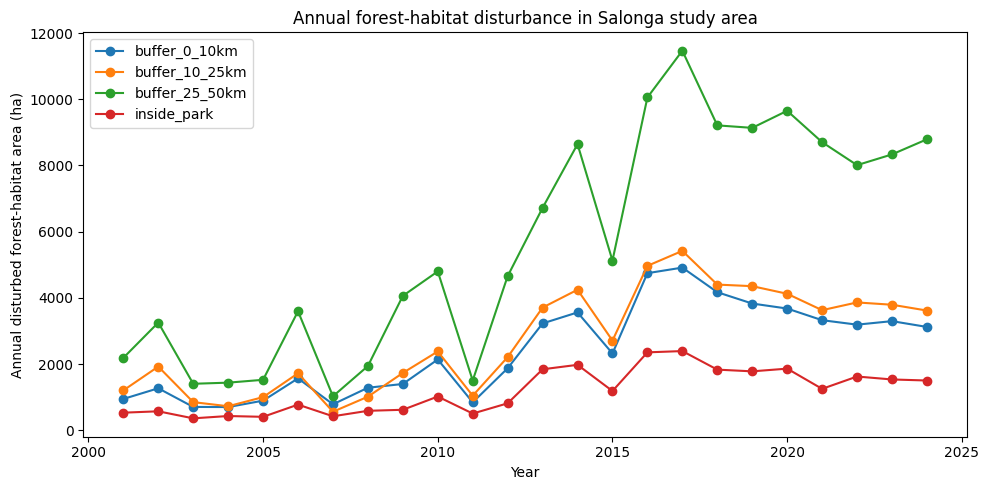

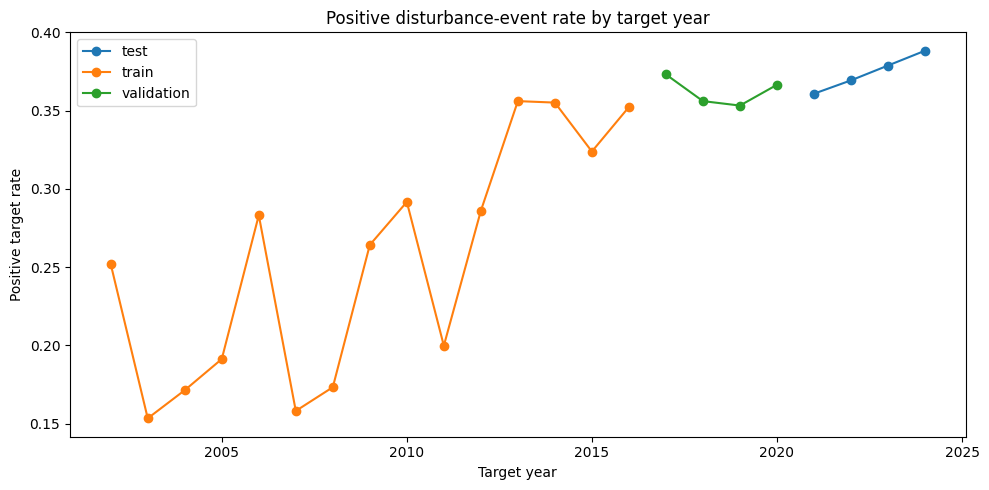

In [20]:

# =============================================================================
# 20. Exploratory summaries and figures
# =============================================================================

annual_zone = (
    loss_df.groupby(["year", "zone"], as_index=False)["loss_area_ha"].sum()
    if "zone" in loss_df.columns else
    loss_df.groupby(["year"], as_index=False)["loss_area_ha"].sum()
)

annual_zone.to_csv(TABLES_DIR / f"annual_loss_by_zone_{GRID_KM}km.csv", index=False)

plt.figure(figsize=(10, 5))
if "zone" in annual_zone.columns:
    for zone, sub in annual_zone.groupby("zone"):
        plt.plot(sub["year"], sub["loss_area_ha"], marker="o", label=str(zone))
    plt.legend()
else:
    plt.plot(annual_zone["year"], annual_zone["loss_area_ha"], marker="o")
plt.xlabel("Year")
plt.ylabel("Annual disturbed forest-habitat area (ha)")
plt.title("Annual forest-habitat disturbance in Salonga study area")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"fig_annual_loss_by_zone_{GRID_KM}km.png", dpi=300)
plt.show()

class_balance = panel.groupby(["split", "target_year"])["target_loss_event_next_year"].agg(["count", "sum", "mean"]).reset_index()
class_balance.to_csv(TABLES_DIR / f"class_balance_by_split_{GRID_KM}km.csv", index=False)

plt.figure(figsize=(10, 5))
for split, sub in class_balance.groupby("split"):
    plt.plot(sub["target_year"], sub["mean"], marker="o", label=split)
plt.xlabel("Target year")
plt.ylabel("Positive target rate")
plt.title("Positive disturbance-event rate by target year")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"fig_positive_rate_by_target_year_{GRID_KM}km.png", dpi=300)
plt.show()

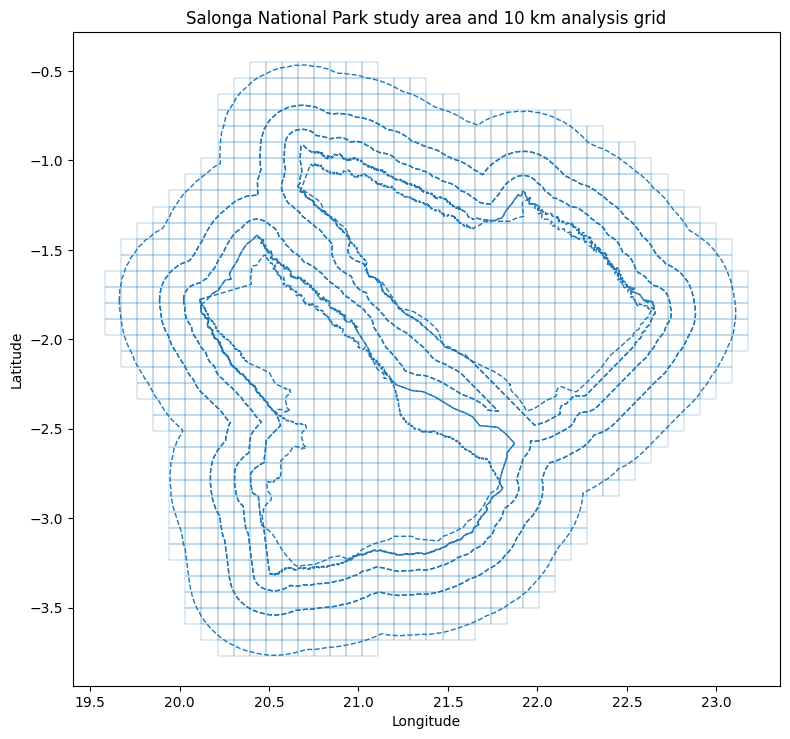

In [21]:

# =============================================================================
# 21. Study area map
# =============================================================================

try:
    if (
        grid_gdf is None or
        "geometry" not in grid_gdf.columns or
        grid_gdf.geometry.isna().all()
    ):
        raise ValueError("Compatible grid geometry is unavailable; study-area map skipped.")

    fig, ax = plt.subplots(figsize=(8, 8))
    grid_plot = grid_gdf[grid_gdf.geometry.notna()].to_crs(epsg=4326)
    grid_plot.boundary.plot(ax=ax, linewidth=0.2)

    if isinstance(PARK_GEOJSON, Path) and PARK_GEOJSON.exists() and "grid" not in PARK_GEOJSON.name.lower():
        try:
            park_gdf = gpd.read_file(PARK_GEOJSON).to_crs(epsg=4326)
            park_gdf.boundary.plot(ax=ax, linewidth=1.2)
        except Exception as e:
            print("Park boundary overlay skipped:", e)

    if isinstance(STUDY_AREA_GEOJSON, Path) and STUDY_AREA_GEOJSON.exists() and "grid" not in STUDY_AREA_GEOJSON.name.lower():
        try:
            study_gdf = gpd.read_file(STUDY_AREA_GEOJSON).to_crs(epsg=4326)
            study_gdf.boundary.plot(ax=ax, linewidth=1.0, linestyle="--")
        except Exception as e:
            print("Study-area overlay skipped:", e)

    ax.set_title(f"Salonga National Park study area and {GRID_KM} km analysis grid")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"fig_study_area_grid_{GRID_KM}km.png", dpi=300)
    plt.show()
except Exception as e:
    print("Study area map failed:", e)


## 9. Baselines and machine-learning models

In [22]:

# =============================================================================
# 22. Model helper functions
# =============================================================================

TARGET = "target_loss_event_next_year"

train_df = panel[panel["split"] == "train"].copy()
val_df = panel[panel["split"] == "validation"].copy()
test_df = panel[panel["split"] == "test"].copy()

X_train = train_df[feature_columns]
y_train = train_df[TARGET].astype(int)

X_val = val_df[feature_columns]
y_val = val_df[TARGET].astype(int)

X_test = test_df[feature_columns]
y_test = test_df[TARGET].astype(int)

print("Train:", X_train.shape, y_train.mean())
print("Validation:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

def safe_auc(metric_func, y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return metric_func(y_true, y_score)
    except Exception:
        return np.nan

def best_f1_threshold(y_true, y_score):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, -1
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return float(best_t)

def recall_at_top_k(y_true, y_score, k_frac=0.10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    n = len(y_true)
    if n == 0:
        return np.nan
    k = max(1, int(math.ceil(k_frac * n)))
    top_idx = np.argsort(-y_score)[:k]
    positives = y_true.sum()
    if positives == 0:
        return np.nan
    return float(y_true[top_idx].sum() / positives)

def precision_at_top_k(y_true, y_score, k_frac=0.10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    n = len(y_true)
    if n == 0:
        return np.nan
    k = max(1, int(math.ceil(k_frac * n)))
    top_idx = np.argsort(-y_score)[:k]
    return float(y_true[top_idx].mean())

def evaluate_scores(model_name, split_name, y_true, y_score, threshold=0.5):
    y_score = np.asarray(y_score, dtype=float)
    y_score = np.clip(y_score, 0, 1)
    y_pred = (y_score >= threshold).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

    return {
        "model": model_name,
        "split": split_name,
        "threshold": threshold,
        "roc_auc": safe_auc(roc_auc_score, y_true, y_score),
        "pr_auc": safe_auc(average_precision_score, y_true, y_score),
        "precision": p,
        "recall": r,
        "f1": f1,
        "brier": brier_score_loss(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan,
        "recall_top_5pct": recall_at_top_k(y_true, y_score, 0.05),
        "recall_top_10pct": recall_at_top_k(y_true, y_score, 0.10),
        "recall_top_20pct": recall_at_top_k(y_true, y_score, 0.20),
        "precision_top_10pct": precision_at_top_k(y_true, y_score, 0.10),
        "n": len(y_true),
        "positive_rate": float(np.mean(y_true))
    }

Train: (15840, 24) 0.25410353535353536
Validation: (4224, 24) 0.3622159090909091
Test: (4224, 24) 0.3742897727272727


In [23]:

# =============================================================================
# 23. Baseline scores
# =============================================================================

results = []
prediction_frames = []

def add_prediction_frame(model_name, df, y_score, split):
    out = df[["cell_id", "year", "target_year", TARGET, "zone"]].copy() if "zone" in df.columns else df[["cell_id", "year", "target_year", TARGET]].copy()
    out["model"] = model_name
    out["split"] = split
    out["y_score"] = np.asarray(y_score, dtype=float)
    return out

# Baseline 1: persistence from current feature year disturbance event.
for split_name, df, y in [("validation", val_df, y_val), ("test", test_df, y_test)]:
    scores = df["loss_event"].astype(float).values
    threshold = best_f1_threshold(y, scores) if split_name == "validation" else 0.5
    if split_name == "validation":
        persistence_threshold = threshold
    else:
        threshold = persistence_threshold
    results.append(evaluate_scores("Persistence", split_name, y, scores, threshold))
    prediction_frames.append(add_prediction_frame("Persistence", df, scores, split_name))

# Baseline 2: rolling three-year disturbance intensity normalized by threshold.
for split_name, df, y in [("validation", val_df, y_val), ("test", test_df, y_test)]:
    scores = (df["loss_rolling_3"].astype(float) / max(LOSS_EVENT_THRESHOLD_HA, 1e-9)).clip(0, 1).values
    threshold = best_f1_threshold(y, scores) if split_name == "validation" else rolling_threshold
    if split_name == "validation":
        rolling_threshold = threshold
    results.append(evaluate_scores("RollingRisk3yr", split_name, y, scores, threshold))
    prediction_frames.append(add_prediction_frame("RollingRisk3yr", df, scores, split_name))

# Baseline 3: historical hotspot from training positive rate by cell.
cell_hotspot = train_df.groupby("cell_id")[TARGET].mean()
global_train_rate = y_train.mean()

for split_name, df, y in [("validation", val_df, y_val), ("test", test_df, y_test)]:
    scores = df["cell_id"].map(cell_hotspot).fillna(global_train_rate).astype(float).values
    threshold = best_f1_threshold(y, scores) if split_name == "validation" else hotspot_threshold
    if split_name == "validation":
        hotspot_threshold = threshold
    results.append(evaluate_scores("HistoricalHotspot", split_name, y, scores, threshold))
    prediction_frames.append(add_prediction_frame("HistoricalHotspot", df, scores, split_name))

pd.DataFrame(results)

,model,split,threshold,roc_auc,pr_auc,precision,recall,f1,brier,recall_top_5pct,recall_top_10pct,recall_top_20pct,precision_top_10pct,n,positive_rate
0,Persistence,validation,0.01,0.957181,0.916897,0.951155,0.941830,0.946470,0.038589,0.126144,0.255556,0.520261,0.924350,4224,0.362216
1,Persistence,test,0.01,0.940666,0.889292,0.933890,0.920304,0.927047,0.054214,0.122075,0.249842,0.503479,0.933806,4224,0.374290
2,RollingRisk3yr,validation,0.87,0.978251,0.949092,0.952663,0.947059,0.949853,0.043782,0.131373,0.264706,0.528758,0.957447,4224,0.362216
3,RollingRisk3yr,test,0.87,0.964244,0.925342,0.929471,0.933586,0.931524,0.057569,0.132827,0.261227,0.509804,0.976359,4224,0.374290
4,HistoricalHotspot,validation,0.14,0.978998,0.972682,0.968071,0.931373,0.949367,0.063624,0.138562,0.276471,0.552288,1.000000,4224,0.362216
5,HistoricalHotspot,test,0.14,0.959168,0.951104,0.963995,0.897533,0.929577,0.075824,0.134092,0.267552,0.534472,1.000000,4224,0.374290


In [24]:

# =============================================================================
# 24. Train machine-learning models
# =============================================================================

models = {}

models["LogisticRegression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

models["RandomForest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

models["ExtraTrees"] = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

if HAS_XGB:
    pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=-1
    )

if HAS_LGBM:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        max_depth=-1,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

thresholds = {}

for name, model in models.items():
    print("\nTraining:", name)
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        val_scores = model.predict_proba(X_val)[:, 1]
        test_scores = model.predict_proba(X_test)[:, 1]
    else:
        val_scores = model.decision_function(X_val)
        test_scores = model.decision_function(X_test)

    val_scores = np.clip(val_scores, 0, 1)
    test_scores = np.clip(test_scores, 0, 1)

    t = best_f1_threshold(y_val, val_scores)
    thresholds[name] = t

    results.append(evaluate_scores(name, "validation", y_val, val_scores, t))
    results.append(evaluate_scores(name, "test", y_test, test_scores, t))

    prediction_frames.append(add_prediction_frame(name, val_df, val_scores, "validation"))
    prediction_frames.append(add_prediction_frame(name, test_df, test_scores, "test"))

    model_path = MODELS_DIR / f"{name}_{GRID_KM}km.joblib"
    joblib.dump(model, model_path)
    print("Saved:", model_path)

performance_df = pd.DataFrame(results)
performance_path = TABLES_DIR / f"model_performance_{GRID_KM}km.csv"
performance_df.to_csv(performance_path, index=False)

thresholds_path = TABLES_DIR / f"model_thresholds_{GRID_KM}km.json"
thresholds_path.write_text(json.dumps(thresholds, indent=2), encoding="utf-8")

predictions_df = pd.concat(prediction_frames, ignore_index=True)
pred_path = PRED_DIR / f"predictions_validation_test_{GRID_KM}km.csv"
predictions_df.to_csv(pred_path, index=False)

print("Saved performance:", performance_path)
display(performance_df.sort_values(["split", "pr_auc"], ascending=[True, False]))


Training: LogisticRegression
Saved: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/models/LogisticRegression_10km.joblib

Training: RandomForest
Saved: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/models/RandomForest_10km.joblib

Training: ExtraTrees
Saved: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/models/ExtraTrees_10km.joblib

Training: XGBoost
Saved: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/models/XGBoost_10km.joblib

Training: LightGBM
Saved: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/models/LightGBM_10km.joblib
Saved performance: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/tables/model_performance_10km.csv


,model,split,threshold,roc_auc,pr_auc,precision,recall,f1,brier,recall_top_5pct,recall_top_10pct,recall_top_20pct,precision_top_10pct,n,positive_rate
9,RandomForest,test,0.63,0.980443,0.980360,0.932075,0.937381,0.934721,0.041512,0.134092,0.267552,0.534472,1.000000,4224,0.374290
11,ExtraTrees,test,0.70,0.980417,0.980076,0.942271,0.929159,0.935669,0.045210,0.134092,0.267552,0.534472,1.000000,4224,0.374290
13,XGBoost,test,0.71,0.980418,0.980034,0.925949,0.941176,0.933501,0.046719,0.134092,0.267552,0.534472,1.000000,4224,0.374290
15,LightGBM,test,0.66,0.979411,0.979096,0.926600,0.934219,0.930394,0.045451,0.134092,0.267552,0.534472,1.000000,4224,0.374290
7,LogisticRegression,test,0.68,0.975890,0.976018,0.954214,0.909551,0.931347,0.045205,0.134092,0.267552,0.534472,1.000000,4224,0.374290
5,HistoricalHotspot,test,0.14,0.959168,0.951104,0.963995,0.897533,0.929577,0.075824,0.134092,0.267552,0.534472,1.000000,4224,0.374290
3,RollingRisk3yr,test,0.87,0.964244,0.925342,0.929471,0.933586,0.931524,0.057569,0.132827,0.261227,0.509804,0.976359,4224,0.374290
1,Persistence,test,0.01,0.940666,0.889292,0.933890,0.920304,0.927047,0.054214,0.122075,0.249842,0.503479,0.933806,4224,0.374290
8,RandomForest,validation,0.63,0.988919,0.987431,0.959103,0.950327,0.954695,0.029851,0.138562,0.276471,0.552288,1.000000,4224,0.362216
14,LightGBM,validation,0.66,0.989251,0.987386,0.952787,0.949673,0.951227,0.030421,0.138562,0.276471,0.552288,1.000000,4224,0.362216


In [25]:

# =============================================================================
# 25. Select final model by validation PR-AUC
# =============================================================================

val_perf = performance_df[performance_df["split"] == "validation"].copy()
val_perf = val_perf.sort_values("pr_auc", ascending=False)
best_model_name = val_perf.iloc[0]["model"]

print("Best model by validation PR-AUC:", best_model_name)
display(val_perf.head())

test_leaderboard = (
    performance_df[performance_df["split"] == "test"]
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)
test_leaderboard.to_csv(TABLES_DIR / f"test_leaderboard_for_paper_{GRID_KM}km.csv", index=False)
display(test_leaderboard)

Best model by validation PR-AUC: RandomForest


,model,split,threshold,roc_auc,pr_auc,precision,recall,f1,brier,recall_top_5pct,recall_top_10pct,recall_top_20pct,precision_top_10pct,n,positive_rate
8,RandomForest,validation,0.63,0.988919,0.987431,0.959103,0.950327,0.954695,0.029851,0.138562,0.276471,0.552288,1.0,4224,0.362216
14,LightGBM,validation,0.66,0.989251,0.987386,0.952787,0.949673,0.951227,0.030421,0.138562,0.276471,0.552288,1.0,4224,0.362216
12,XGBoost,validation,0.71,0.988575,0.987167,0.954188,0.952941,0.953564,0.032320,0.138562,0.276471,0.552288,1.0,4224,0.362216
10,ExtraTrees,validation,0.70,0.986972,0.986180,0.956436,0.947059,0.951724,0.035380,0.138562,0.276471,0.552288,1.0,4224,0.362216
6,LogisticRegression,validation,0.68,0.982790,0.982143,0.975978,0.929412,0.952126,0.034595,0.138562,0.276471,0.552288,1.0,4224,0.362216


,model,split,threshold,roc_auc,pr_auc,precision,recall,f1,brier,recall_top_5pct,recall_top_10pct,recall_top_20pct,precision_top_10pct,n,positive_rate
0,RandomForest,test,0.63,0.980443,0.980360,0.932075,0.937381,0.934721,0.041512,0.134092,0.267552,0.534472,1.000000,4224,0.37429
1,ExtraTrees,test,0.70,0.980417,0.980076,0.942271,0.929159,0.935669,0.045210,0.134092,0.267552,0.534472,1.000000,4224,0.37429
2,XGBoost,test,0.71,0.980418,0.980034,0.925949,0.941176,0.933501,0.046719,0.134092,0.267552,0.534472,1.000000,4224,0.37429
3,LightGBM,test,0.66,0.979411,0.979096,0.926600,0.934219,0.930394,0.045451,0.134092,0.267552,0.534472,1.000000,4224,0.37429
4,LogisticRegression,test,0.68,0.975890,0.976018,0.954214,0.909551,0.931347,0.045205,0.134092,0.267552,0.534472,1.000000,4224,0.37429
5,HistoricalHotspot,test,0.14,0.959168,0.951104,0.963995,0.897533,0.929577,0.075824,0.134092,0.267552,0.534472,1.000000,4224,0.37429
6,RollingRisk3yr,test,0.87,0.964244,0.925342,0.929471,0.933586,0.931524,0.057569,0.132827,0.261227,0.509804,0.976359,4224,0.37429
7,Persistence,test,0.01,0.940666,0.889292,0.933890,0.920304,0.927047,0.054214,0.122075,0.249842,0.503479,0.933806,4224,0.37429


## 10. Paper-ready performance and interpretation figures

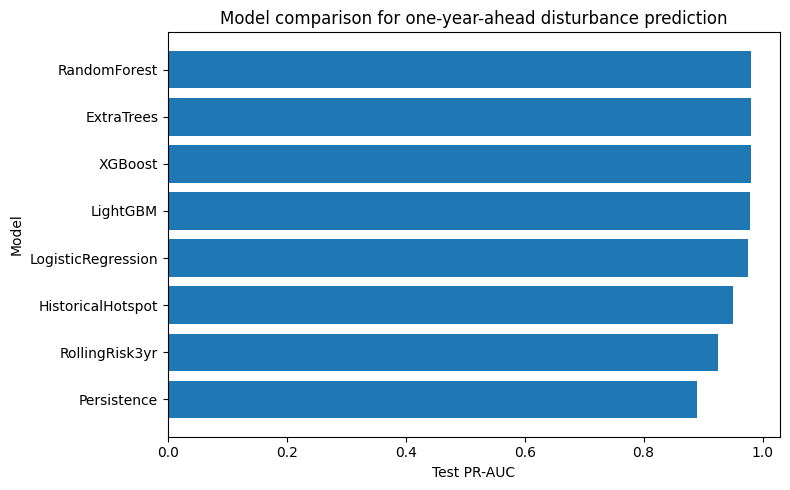

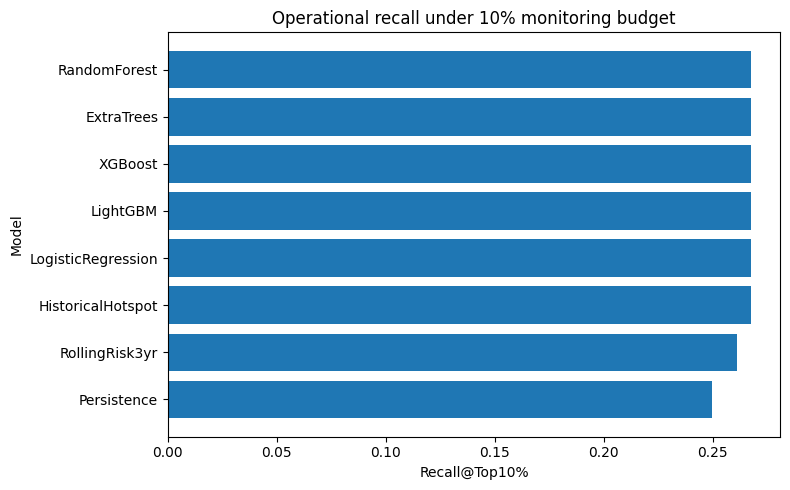

In [26]:

# =============================================================================
# 26. Model comparison figure
# =============================================================================

test_perf = performance_df[performance_df["split"] == "test"].copy().sort_values("pr_auc", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(test_perf["model"], test_perf["pr_auc"])
plt.xlabel("Test PR-AUC")
plt.ylabel("Model")
plt.title("Model comparison for one-year-ahead disturbance prediction")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"fig_model_comparison_pr_auc_{GRID_KM}km.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(test_perf["model"], test_perf["recall_top_10pct"])
plt.xlabel("Recall@Top10%")
plt.ylabel("Model")
plt.title("Operational recall under 10% monitoring budget")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"fig_recall_top10_monitoring_budget_{GRID_KM}km.png", dpi=300)
plt.show()

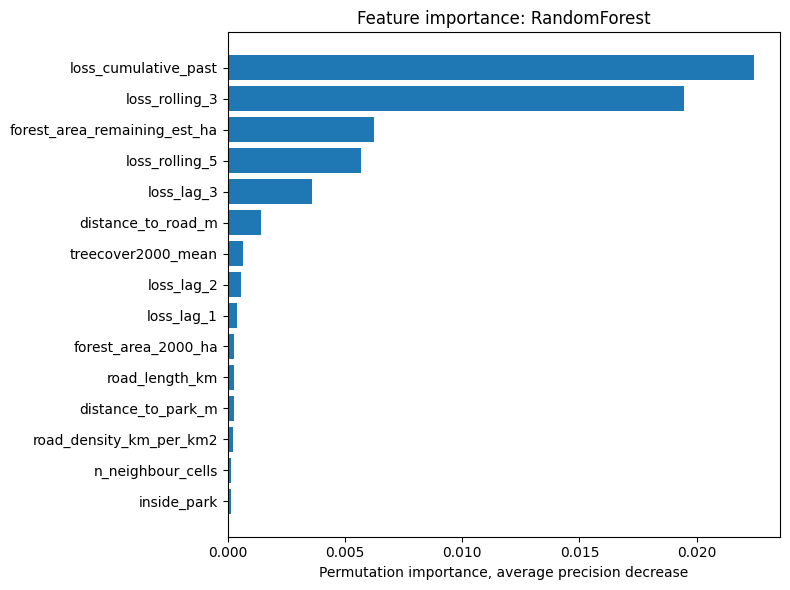

,feature,importance_mean,importance_std
8,loss_cumulative_past,0.022432,0.002289
6,loss_rolling_3,0.019438,0.002233
10,forest_area_remaining_est_ha,0.006253,0.000589
7,loss_rolling_5,0.005668,0.001198
2,loss_lag_3,0.003601,0.000838
14,distance_to_road_m,0.001430,0.000436
11,treecover2000_mean,0.000660,0.000171
1,loss_lag_2,0.000553,0.000322
0,loss_lag_1,0.000379,0.000516
9,forest_area_2000_ha,0.000281,0.000125


In [27]:

# =============================================================================
# 27. Feature importance for the best ML model, if available
# =============================================================================

if best_model_name in models:
    best_model = models[best_model_name]

    try:
        perm = permutation_importance(
            best_model, X_test, y_test,
            n_repeats=5,
            random_state=42,
            scoring="average_precision",
            n_jobs=-1
        )

        imp_df = pd.DataFrame({
            "feature": feature_columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std
        }).sort_values("importance_mean", ascending=False)

        imp_path = TABLES_DIR / f"feature_importance_permutation_{GRID_KM}km.csv"
        imp_df.to_csv(imp_path, index=False)

        top_imp = imp_df.head(15).sort_values("importance_mean", ascending=True)

        plt.figure(figsize=(8, 6))
        plt.barh(top_imp["feature"], top_imp["importance_mean"])
        plt.xlabel("Permutation importance, average precision decrease")
        plt.title(f"Feature importance: {best_model_name}")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"fig_feature_importance_{GRID_KM}km.png", dpi=300)
        plt.show()

        display(imp_df.head(20))

    except Exception as e:
        print("Permutation importance failed:", e)
else:
    print("Best model is a baseline; no feature importance computed.")

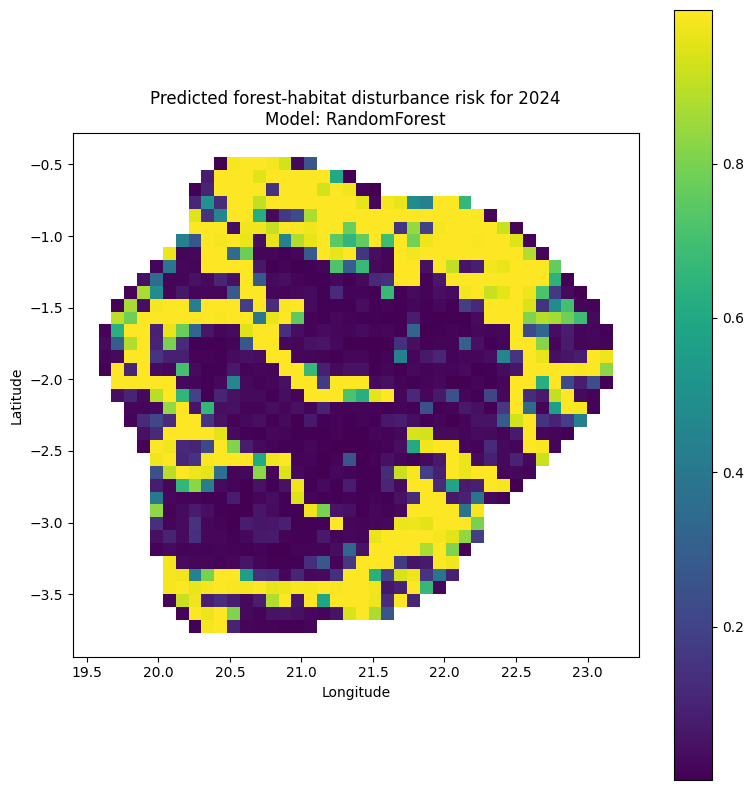

In [28]:

# =============================================================================
# 28. Risk map for the best model on the latest test target year
# =============================================================================

try:
    if (
        grid_gdf is None or
        "geometry" not in grid_gdf.columns or
        grid_gdf.geometry.isna().all() or
        len(set(grid_gdf["cell_id"].astype(str)) & set(predictions_df["cell_id"].astype(str))) == 0
    ):
        raise ValueError("Compatible grid geometry is unavailable; risk map skipped.")

    latest_target_year = int(test_df["target_year"].max())

    best_pred = predictions_df[
        (predictions_df["model"] == best_model_name) &
        (predictions_df["split"] == "test") &
        (predictions_df["target_year"] == latest_target_year)
    ].copy()

    if best_pred.empty:
        print("No predictions found for best model; using top test predictions available.")
        best_pred = predictions_df[
            (predictions_df["split"] == "test") &
            (predictions_df["target_year"] == latest_target_year)
        ].copy()

    map_gdf = grid_gdf.merge(best_pred[["cell_id", "y_score", TARGET]], on="cell_id", how="left")
    map_gdf["y_score"] = map_gdf["y_score"].fillna(0.0)

    fig, ax = plt.subplots(figsize=(8, 8))
    map_gdf.to_crs(epsg=4326).plot(
        column="y_score",
        ax=ax,
        legend=True,
        linewidth=0.05,
        edgecolor="none"
    )

    if PARK_GEOJSON.exists():
        park_gdf = gpd.read_file(PARK_GEOJSON).to_crs(epsg=4326)
        park_gdf.boundary.plot(ax=ax, linewidth=1.0)

    ax.set_title(f"Predicted forest-habitat disturbance risk for {latest_target_year}\nModel: {best_model_name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"fig_predicted_risk_map_{latest_target_year}_{GRID_KM}km.png", dpi=300)
    plt.show()

except Exception as e:
    print("Risk map skipped/failed:", e)


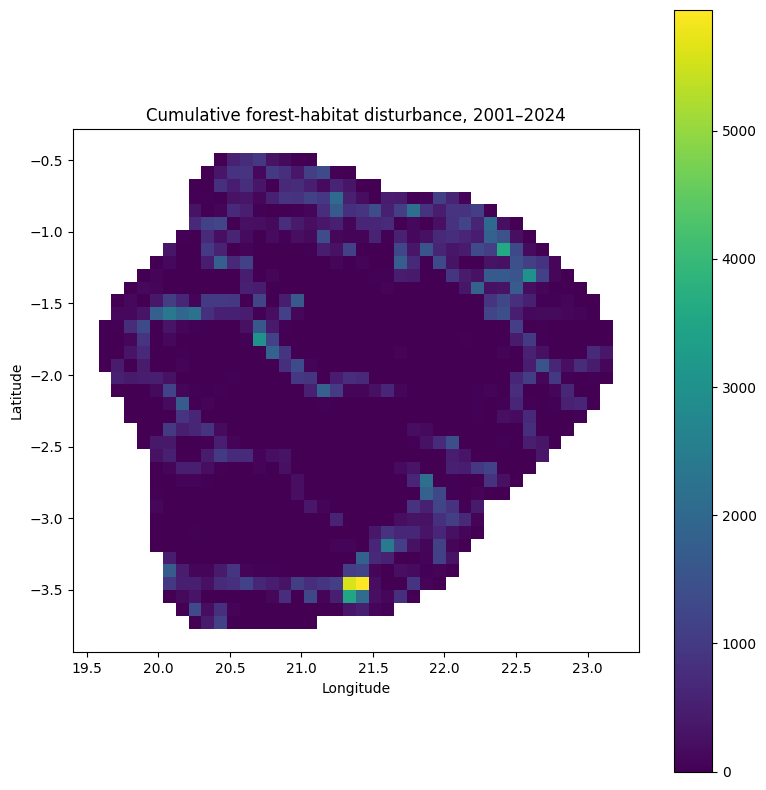

In [29]:

# =============================================================================
# 29. Historical cumulative disturbance map
# =============================================================================

try:
    if (
        grid_gdf is None or
        "geometry" not in grid_gdf.columns or
        grid_gdf.geometry.isna().all() or
        len(set(grid_gdf["cell_id"].astype(str)) & set(loss_df["cell_id"].astype(str))) == 0
    ):
        raise ValueError("Compatible grid geometry is unavailable; cumulative map skipped.")

    cumulative_loss = loss_df.groupby("cell_id", as_index=False)["loss_area_ha"].sum()
    hist_gdf = grid_gdf.merge(cumulative_loss, on="cell_id", how="left")
    hist_gdf["loss_area_ha"] = hist_gdf["loss_area_ha"].fillna(0.0)

    fig, ax = plt.subplots(figsize=(8, 8))
    hist_gdf.to_crs(epsg=4326).plot(
        column="loss_area_ha",
        ax=ax,
        legend=True,
        linewidth=0.05,
        edgecolor="none"
    )

    if PARK_GEOJSON.exists():
        park_gdf = gpd.read_file(PARK_GEOJSON).to_crs(epsg=4326)
        park_gdf.boundary.plot(ax=ax, linewidth=1.0)

    ax.set_title("Cumulative forest-habitat disturbance, 2001–2024")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"fig_cumulative_loss_map_2001_2024_{GRID_KM}km.png", dpi=300)
    plt.show()

except Exception as e:
    print("Cumulative loss map skipped/failed:", e)


## 11. Final manifest and release ZIP

In [30]:

# =============================================================================
# 30. Create manifest of important outputs
# =============================================================================

manifest = {
    "project_title": "A Spatio-Temporal Machine Learning Benchmark for Forest-Habitat Disturbance Prediction around Salonga National Park",
    "grid_km": GRID_KM,
    "buffer_km": BUFFER_KM,
    "years": YEARS,
    "treecover_threshold": TREECOVER_THRESHOLD,
    "loss_event_threshold_ha": LOSS_EVENT_THRESHOLD_HA,
    "target_definition": "target_loss_event_next_year = 1 if forest-habitat loss area in target year >= threshold",
    "split_by_target_year": {
        "train_end": TRAIN_TARGET_END,
        "validation": [VAL_TARGET_START, VAL_TARGET_END],
        "test": [TEST_TARGET_START, TEST_TARGET_END]
    },
    "feature_columns": feature_columns,
    "best_model_by_validation_pr_auc": best_model_name,
    "key_outputs": {
        "panel": str(panel_path),
        "performance": str(performance_path),
        "test_leaderboard": str(TABLES_DIR / f"test_leaderboard_for_paper_{GRID_KM}km.csv"),
        "predictions": str(pred_path),
        "figures_dir": str(FIGURES_DIR),
        "tables_dir": str(TABLES_DIR),
        "models_dir": str(MODELS_DIR)
    }
}

manifest_path = OUTPUTS_DIR / f"study_manifest_{GRID_KM}km.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Manifest saved:", manifest_path)
print(json.dumps(manifest, indent=2)[:3000])

Manifest saved: /content/drive/MyDrive/salonga_forest_habitat_ml/outputs/study_manifest_10km.json
{
  "project_title": "A Spatio-Temporal Machine Learning Benchmark for Forest-Habitat Disturbance Prediction around Salonga National Park",
  "grid_km": 10,
  "buffer_km": 50,
  "years": [
    2001,
    2002,
    2003,
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023,
    2024
  ],
  "treecover_threshold": 30,
  "loss_event_threshold_ha": 5.0,
  "target_definition": "target_loss_event_next_year = 1 if forest-habitat loss area in target year >= threshold",
  "split_by_target_year": {
    "train_end": 2016,
    "validation": [
      2017,
      2020
    ],
    "test": [
      2021,
      2024
    ]
  },
  "feature_columns": [
    "loss_lag_1",
    "loss_lag_2",
    "loss_lag_3",
    "event_lag_1",
    "event_lag_2",
    "event_lag_3",
    "loss

In [31]:
# =============================================================================
# 31. Create a ZIP archive of the complete project folder
# =============================================================================

zip_base = DRIVE_ROOT / f"salonga_forest_habitat_ml_release_{GRID_KM}km"

# Remove any previous archive with the same name to avoid confusion.
old_zip = zip_base.with_suffix(".zip")
if old_zip.exists():
    old_zip.unlink()

zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(PROJECT_DIR))

print("Project ZIP created:")
print(zip_path)

# Optional quick check.
print("ZIP size (MB):", round(Path(zip_path).stat().st_size / (1024 * 1024), 2))


Project ZIP created:
/content/drive/MyDrive/salonga_forest_habitat_ml_release_10km.zip
ZIP size (MB): 354.1


## 12. What to report in the paper

Recommended paper figures:

1. `fig_study_area_grid_10km.png` — Salonga, buffer and analysis grid.  
2. `fig_cumulative_loss_map_2001_2024_10km.png` — historical forest-habitat disturbance.  
3. `fig_annual_loss_by_zone_10km.png` — annual disturbance inside the park and buffer zones.  
4. `fig_model_comparison_pr_auc_10km.png` — predictive performance comparison.  
5. `fig_recall_top10_monitoring_budget_10km.png` — operational monitoring-budget evaluation.  
6. `fig_predicted_risk_map_<year>_10km.png` — final risk map.

Recommended result table:

- `test_leaderboard_for_paper_10km.csv`

Recommended scientific claim:

> The study evaluates whether open spatio-temporal geospatial data and machine learning can predict one-year-ahead forest-habitat disturbance risk around Salonga National Park, with performance assessed against historical baselines and monitoring-budget metrics relevant to biodiversity management.

Do not claim direct biodiversity-loss prediction unless species-level data are added.